In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Retail_Dataset_Modified (3).csv")

In [4]:
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_ID               5171 non-null   object 
 1   Store_Name             5171 non-null   object 
 2   Brand_Name             5171 non-null   object 
 3   Store_Type             5171 non-null   object 
 4   City                   5109 non-null   object 
 5   City_Tier              5171 non-null   object 
 6   Product_Name           5098 non-null   object 
 7   Category               5171 non-null   object 
 8   Sub_Category           5171 non-null   object 
 9   Product_Stage          5171 non-null   object 
 10  Quantity_Available     5171 non-null   object 
 11  Units_Sold             5171 non-null   object 
 12  Unit_Price             5171 non-null   int64  
 13  Cost_Price             5171 non-null   int64  
 14  Revenue                5099 non-null   object 
 15  Prof

,0
Store_ID,0
Store_Name,0
Brand_Name,0
Store_Type,0
City,62
City_Tier,0
Product_Name,73
Category,0
Sub_Category,0
Product_Stage,0


In [5]:
numeric_cols = [
    'Quantity_Available',
    'Units_Sold',
    'Revenue',
    'Shipping_Cost'

]
for col in numeric_cols:
   df[col]= pd.to_numeric(df[col], errors='coerce')

In [6]:
num_cols = ['Quantity_Available', 'Units_Sold',
			'Revenue','Customer_Satisfaction',
            'Delivery_Time', 'Shipping_Cost']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1531/2024215013.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [7]:
cat_cols = ['City', 'Product_Name','Supplier']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1531/324042983.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
df.duplicated().sum()

np.int64(25)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(5146, 47)

In [12]:
df['Category'] = df['Category'].str.strip().str.title()

df['Category'].unique()

array(['Groceries', 'Clothes', 'Gadgets', 'Electronics',
       'Home Appliances'], dtype=object)

In [13]:
df["Profit_Amount"] = (
    df["Revenue"] *
    df["Profit_Margin"] / 100
)

df[["Revenue",
    "Profit_Margin",
    "Profit_Amount"]].sample(5)

,Revenue,Profit_Margin,Profit_Amount
3770,1760990.0,29.72,523366.2280
2561,59962.0,28.06,16825.3372
3351,2808311.0,20.64,579635.3904
1125,2045550.0,18.07,369630.8850
3388,2004156.0,26.63,533706.7428


In [14]:
df["Revenue_Category"] = np.where(
    df["Revenue"] < 5000,
    "Low Revenue",
    np.where(
        df["Revenue"] < 10000,
        "Medium Revenue",
        "High Revenue"
    )
)

df[["Revenue", "Revenue_Category"]].head()

,Revenue,Revenue_Category
0,7320.0,Medium Revenue
1,1645.0,Low Revenue
2,66340.0,High Revenue
3,77748.0,High Revenue
4,1976364.0,High Revenue


In [15]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 5146 entries, 0 to 5170
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_ID               5146 non-null   object 
 1   Store_Name             5146 non-null   object 
 2   Brand_Name             5146 non-null   object 
 3   Store_Type             5146 non-null   object 
 4   City                   5146 non-null   object 
 5   City_Tier              5146 non-null   object 
 6   Product_Name           5146 non-null   object 
 7   Category               5146 non-null   object 
 8   Sub_Category           5146 non-null   object 
 9   Product_Stage          5146 non-null   object 
 10  Quantity_Available     5146 non-null   float64
 11  Units_Sold             5146 non-null   float64
 12  Unit_Price             5146 non-null   int64  
 13  Cost_Price             5146 non-null   int64  
 14  Revenue                5146 non-null   float64
 15  Profit_Ma

(5146, 49)

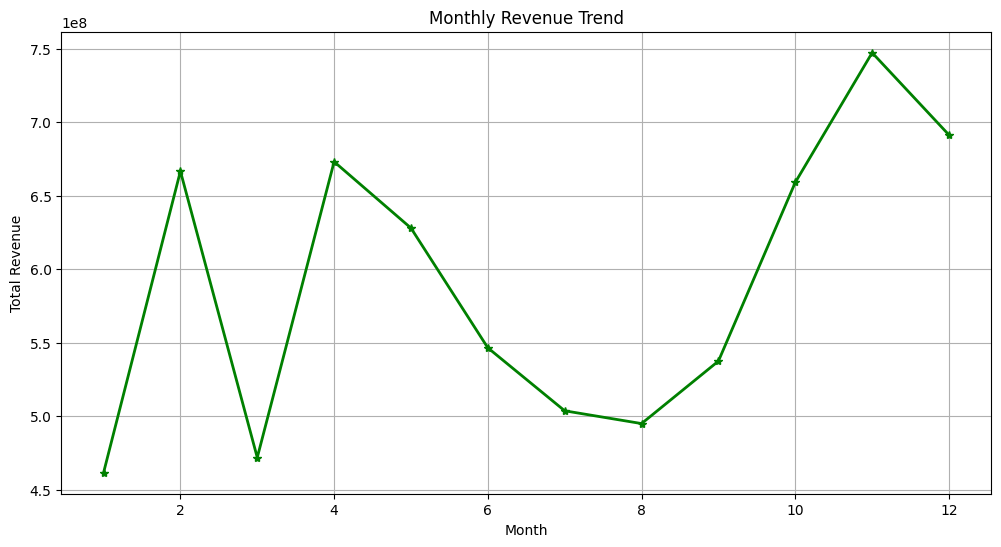

In [20]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(12,6))
plt.plot( monthly_revenue.index, monthly_revenue.values, marker='*', linewidth=2, color='green' )
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

/tmp/ipykernel_1531/3422580595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x=category_revenue.index, y=category_revenue.values, palette='viridis', color='blue', edgecolor='black', alpha=0.8 )


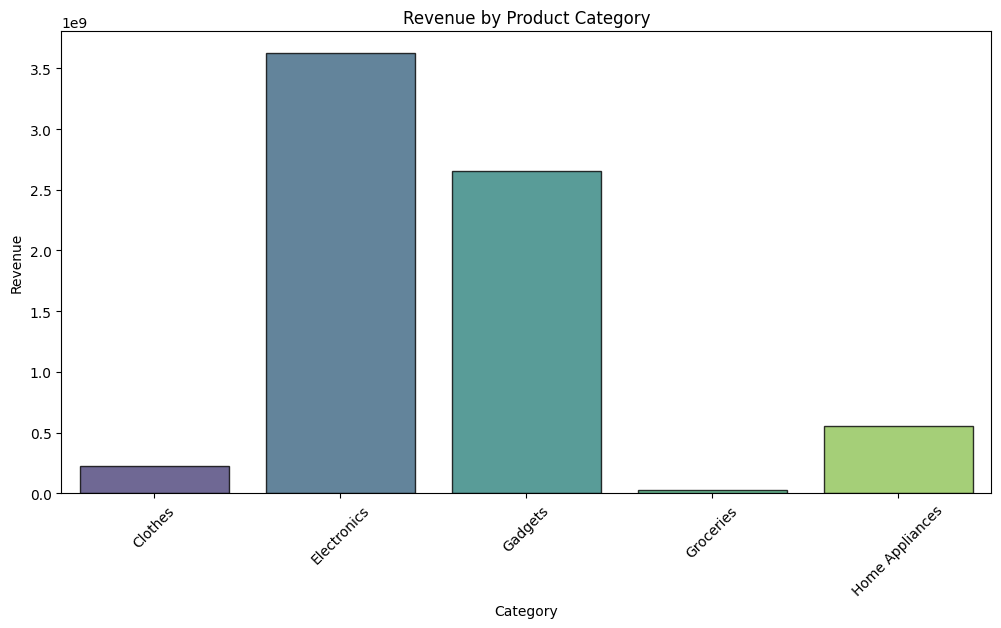

In [23]:
category_revenue = df.groupby('Category')['Revenue'].sum()
plt.figure(figsize=(12,6))
sns.barplot( x=category_revenue.index, y=category_revenue.values, palette='viridis', color='blue', edgecolor='black', alpha=0.8 )
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

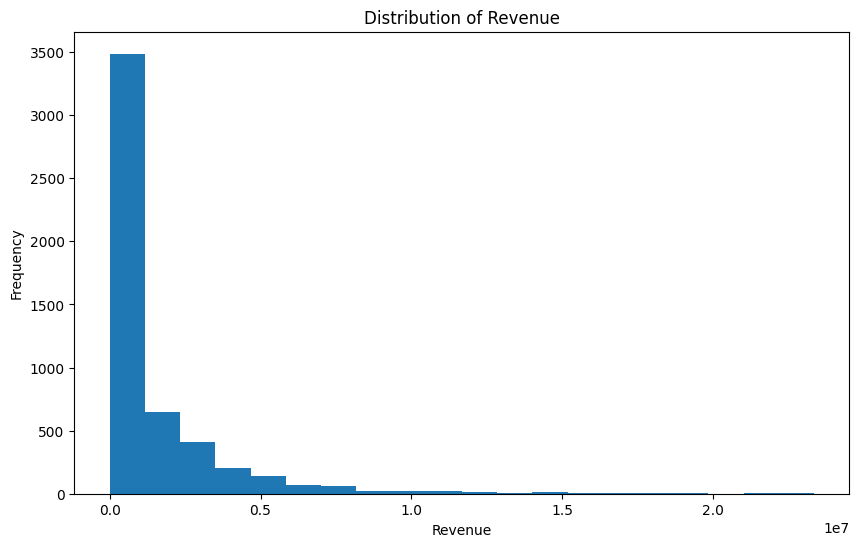

In [24]:
plt.figure(figsize=(10,6))
plt.hist( df['Revenue'], bins=20 )
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

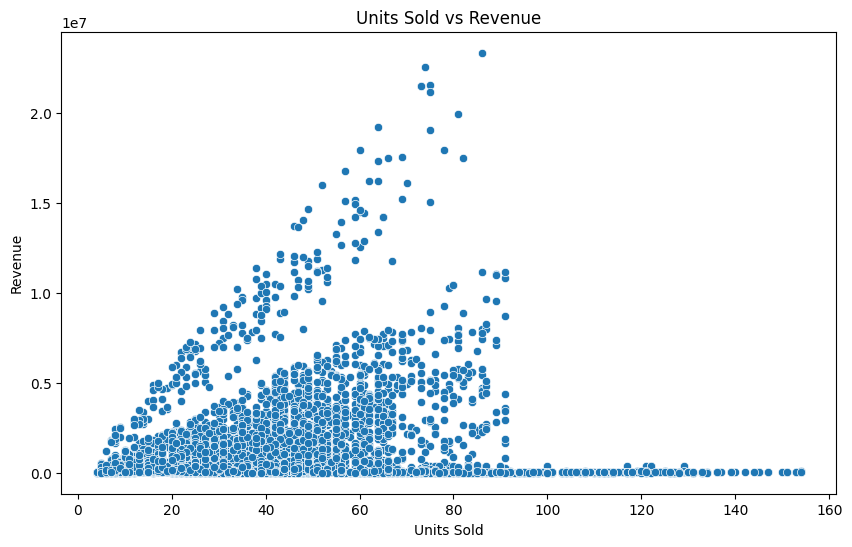

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot( data=df, x='Units_Sold', y='Revenue' )
plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')
plt.show()

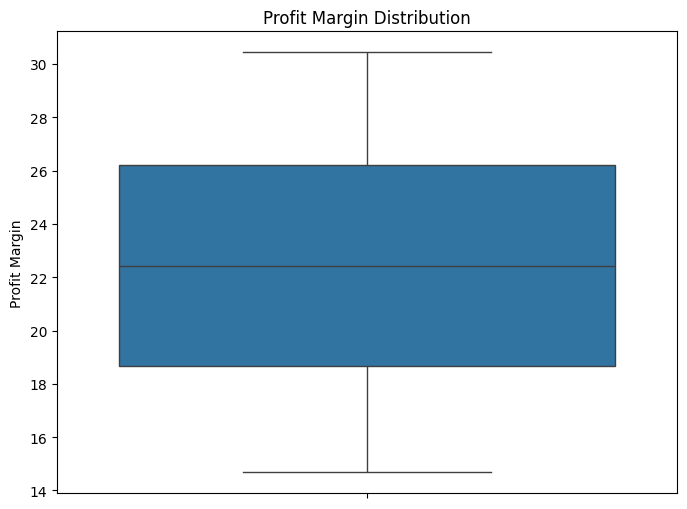

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot( y=df['Profit_Margin'] )
plt.title('Profit Margin Distribution')
plt.ylabel('Profit Margin')
plt.show()

In [27]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()
print("Highest Revenue Month:", highest_month)
print("Revenue:", highest_revenue)

Highest Revenue Month: 11
Revenue: 747398971.0


In [28]:
category_revenue = df.groupby('Category')['Revenue'].sum()
top_category = category_revenue.idxmax()
top_revenue = category_revenue.max()
print("Top Category:", top_category)
print("Revenue:", top_revenue)

Top Category: Electronics
Revenue: 3623060564.0
